In [1]:
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)

- `value_counts()` 메서드: 고유값의 등장 횟수를 계산하는 함수  

In [2]:
count_by_year = ns_book7['발행년도'].value_counts()
count_by_year

발행년도
2012    18601
2014    17797
2009    17611
2011    17523
2010    17503
        ...  
2650        1
2108        1
2104        1
2560        1
1947        1
Name: count, Length: 87, dtype: int64

- `sort_index()` 메서드: 시리즈 객체의 인덱스 순서대로 데이터를 정렬하는 함수

In [3]:
count_by_year = count_by_year.sort_index()
count_by_year

발행년도
1947     1
1948     1
1949     1
1952    11
1954     1
        ..
2551     1
2552     2
2559     1
2560     1
2650     1
Name: count, Length: 87, dtype: int64

In [4]:
count_by_year = count_by_year[count_by_year.index <= 2030]
count_by_year

발행년도
1947        1
1948        1
1949        1
1952       11
1954        1
        ...  
2020    11834
2021     1255
2025        1
2028        1
2030        1
Name: count, Length: 68, dtype: int64

- **명목형 데이터**: 순서를 매길 수 없는 데이터  
- **순서형 데이터**: 순서가 있는 데이터

In [5]:
# value_counts() 적용 예시
import numpy as np 

def kdc_1st_char(no):   # '주제분류번호' 열의 값이 NaN인 경우 -1, 그렇지 않은 경우 첫 문자 반환
    if no is np.nan:
        return '-1'
    else:
        return no[0]

count_by_subject = ns_book7['주제분류번호'].apply(kdc_1st_char).value_counts()
count_by_subject

주제분류번호
8     108643
3      80767
5      40916
9      26375
6      25070
1      22647
-1     16978
7      15836
4      13688
2      13474
0      12376
Name: count, dtype: int64

- `plot()` 함수를 이용하면 선 그래프를 그릴 수 있음

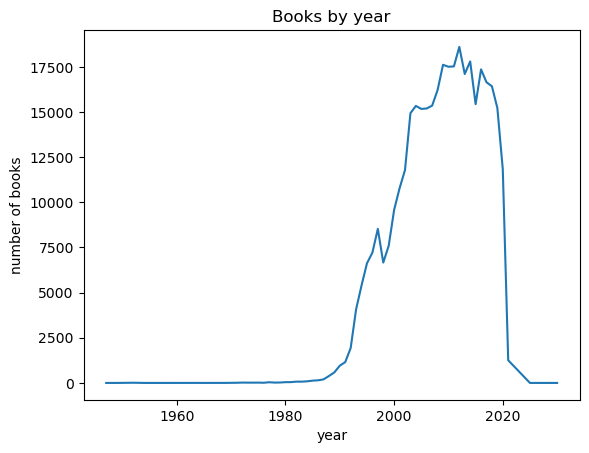

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100    # 기본 DPI 값 설정 

plt.plot(count_by_year.index, count_by_year.values)
plt.title('Books by year')  # 그래프 제목
plt.xlabel('year')  # x축 이름
plt.ylabel('number of books')   # y축 이름
plt.show()

- `plot()` 함수의 `linestyle` 매개변수를 통해서 선 모양 지정 가능
- 실선: '-'  
- 점선: ':'  
- 쇄선: '-.'  
- 파선: '--' 
- `color` 매개변수: 색상을 지정  
- `marker` 매개변수: 그래프 모양 변경

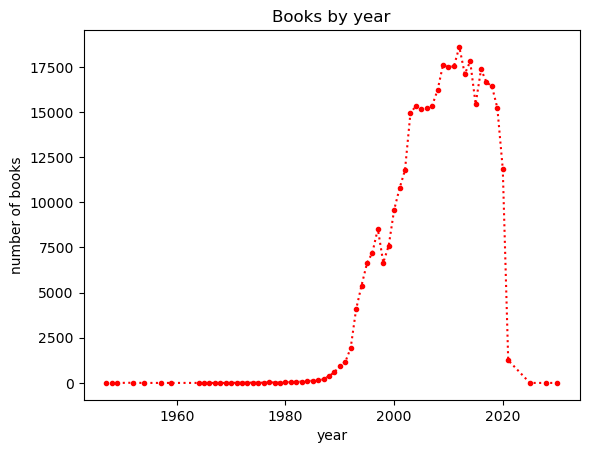

In [ ]:
plt.plot(count_by_year, marker='.', linestyle=':', color='red')

# plt.plot(count_by_year, '.:r')   
# -> 마커, 선 모양, 색깔 옵션을 하나의 문자열로 지정 가능

plt.title('Books by year')  # 그래프 제목
plt.xlabel('year')  # x축 이름
plt.ylabel('number of books')   # y축 이름
plt.show()

- `xticks()` 함수: x축의 눈금을 지정하는 함수  
- `yticks()` 함수: y축의 눈금을 지정하는 함수  
- `annotate()` 함수: 그래프에 값을 표시하는 함수  
    - 첫 번째 매개변수에 그래프에 나타낼 문자열, 두 번째 매개변수에는 문자열이 나타날 x, y 좌표의 튜플  
    - `xytext` 매개변수: 마커로부터 텍스트 위치를 조절하는 매개변수  
    - `textcoords` 매개변수: `xytext`와 함께 상대 위치를 나타내는 `offset points`를 사용

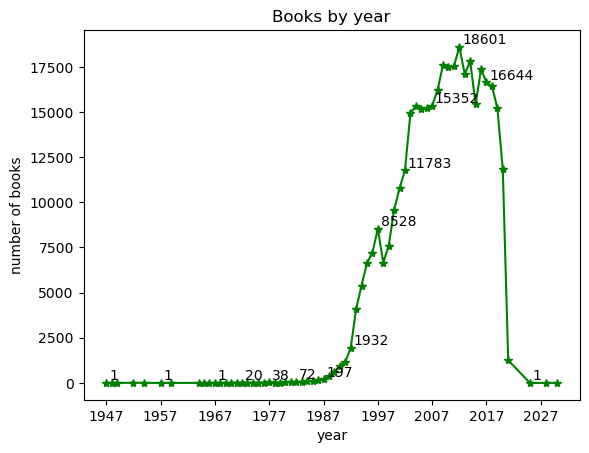

In [8]:
plt.plot(count_by_year, '*-g')
plt.title('Books by year')  
plt.xlabel('year')  
plt.ylabel('number of books')   

plt.xticks(range(1947, 2030, 10))
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(2,2), textcoords='offset points')
plt.show()

- `bar()` 함수: 막대 그래프를 그릴 수 있는 함수  

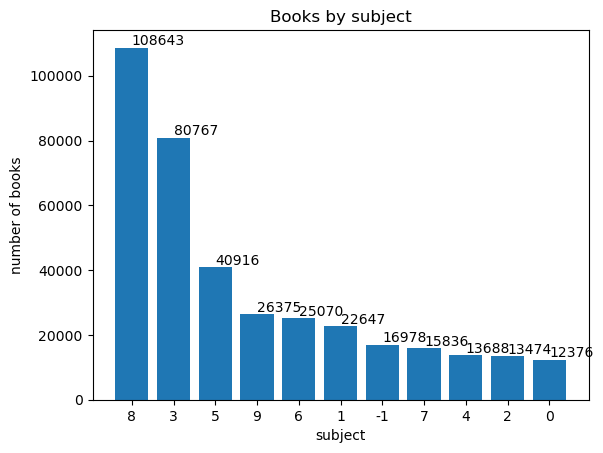

In [9]:
plt.bar(count_by_subject.index, count_by_subject.values)
plt.title('Books by subject')  
plt.xlabel('subject')  
plt.ylabel('number of books')   

for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0,2), textcoords='offset points')
plt.show()

- `annotate()` 함수의 매개변수  

    - `ha` 매개변수: 텍스트 위치 조절(기본값: right, center, left, right)  
    - `fontsize` 매개변수: 텍스트 크기 조절  
    - `color` 매개변수: 텍스트 색깔 지정   

- `bar()` 함수의 매개변수  
    - `width` 매개변수: 막대의 두께를 조절  
    - `color` 매개변수: 막대의 색깔을 지정  

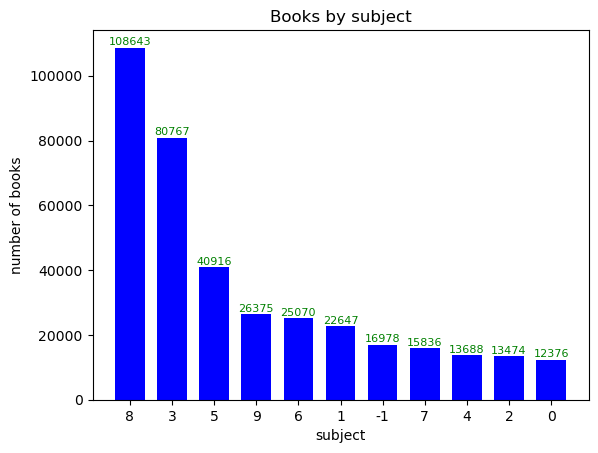

In [10]:
plt.bar(count_by_subject.index, count_by_subject.values, width=0.7, color='blue')
plt.title('Books by subject')  
plt.xlabel('subject')  
plt.ylabel('number of books')   

for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0,2), textcoords='offset points', fontsize=8, ha='center', color='green')
plt.show()

- `barh()` 함수: 가로 막대 그래프를 그리는 함수
- width 대신 `height` 매개변수 사용  
- ha 대신 `va` 매개변수 사용

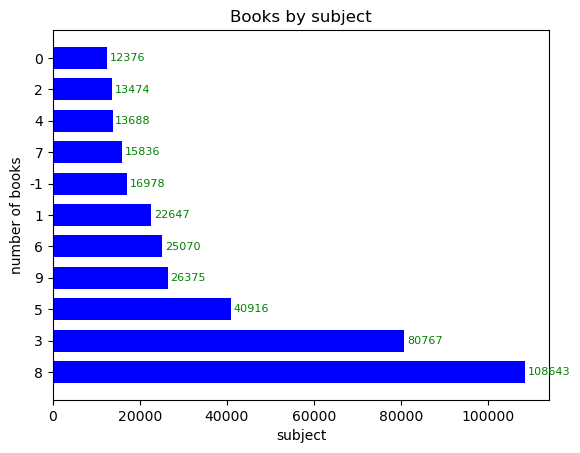

In [11]:
plt.barh(count_by_subject.index, count_by_subject.values, height=0.7, color='blue')
plt.title('Books by subject')  
plt.xlabel('subject')  
plt.ylabel('number of books')   

for idx, val in count_by_subject.items():
    plt.annotate(val, (val, idx), xytext=(2,0), textcoords='offset points', fontsize=8, va='center', color='green')
plt.show()